# Transport impact — Figure 4

Compare the SeapoPym mean zooplankton biomass against the reference SEAPODYM-LMTL
biomass over the analysis period (Manuscript Section 3.2):

- (a) Mean biomass distribution predicted by SeapoPym
- (b) Spatial RMSE between SeapoPym and LMTL

Inputs: `data/biomass_global.zarr`, `data/forcings_global.zarr`.
Output: `figures/Figure_4.{pdf,png}`.
Runtime: ~1-2 minutes.

In [1]:
from datetime import datetime, timedelta
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cf_xarray.units  # noqa: F401  (registers CF unit conversions on pint)
import matplotlib.pyplot as plt
import numpy as np
import pint_xarray  # noqa: F401  (xarray .pint accessor)
import xarray as xr
import yaml


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    GS = yaml.safe_load(f)["global_simulation"]
T_ANALYSIS_START = (datetime.strptime(GS["spin_up_end"], "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")
T_END = GS[GS["mode"]]["end_date"]
print(f"Mode: {GS['mode']} | analysis period: {T_ANALYSIS_START} -> {T_END}")

Mode: test | analysis period: 2000-01-01 -> 2003-12-31


## Load both biomass fields and convert to `g m-2`

In [2]:
time_slice = slice(T_ANALYSIS_START, T_END)

pred = (
    xr.open_zarr(DATA_DIR / "biomass_global.zarr")["biomass"]
    .sel(T=time_slice, functional_group=0, drop=True)
    .pint.quantify().pint.to("g/m^2").pint.dequantify()
)
obs = (
    xr.open_zarr(DATA_DIR / "forcings_global.zarr")["zooc"]
    .sel(T=time_slice)
    .pint.quantify().pint.to("g/m^2").pint.dequantify()
)

mask = ~obs.isel(T=0).isnull()
pred = pred.where(mask)
obs = obs.where(mask)

pred_mean = pred.mean("T", skipna=False).compute()
obs_mean = obs.mean("T", skipna=False).compute()
spatial_rmse = np.sqrt(((pred - obs) ** 2).mean("T", skipna=False)).compute()

In [3]:
def add_cyclic_point(da: xr.DataArray, lon_name: str = "X") -> xr.DataArray:
    extra = da.isel({lon_name: 0})
    out = xr.concat([da, extra], dim=lon_name)
    return out.assign_coords({lon_name: list(da[lon_name].values) + [180]})


pred_mean = add_cyclic_point(pred_mean)
spatial_rmse = add_cyclic_point(spatial_rmse)
rmse_flat = np.ravel(spatial_rmse.data)
rmse_flat = rmse_flat[np.isfinite(rmse_flat)]
print(f"Global RMSE = {np.sqrt(np.nanmean((pred - obs).values ** 2)):.3f} g/m^2")
print(f"Spatial RMSE median = {np.nanmedian(rmse_flat):.3f}, 95th pct = {np.nanpercentile(rmse_flat, 95):.3f} g/m^2")

Global RMSE = 1.436 g/m^2
Spatial RMSE median = 0.161, 95th pct = 1.375 g/m^2


## Figure 4 — (a) SeapoPym mean biomass and (b) spatial RMSE vs LMTL

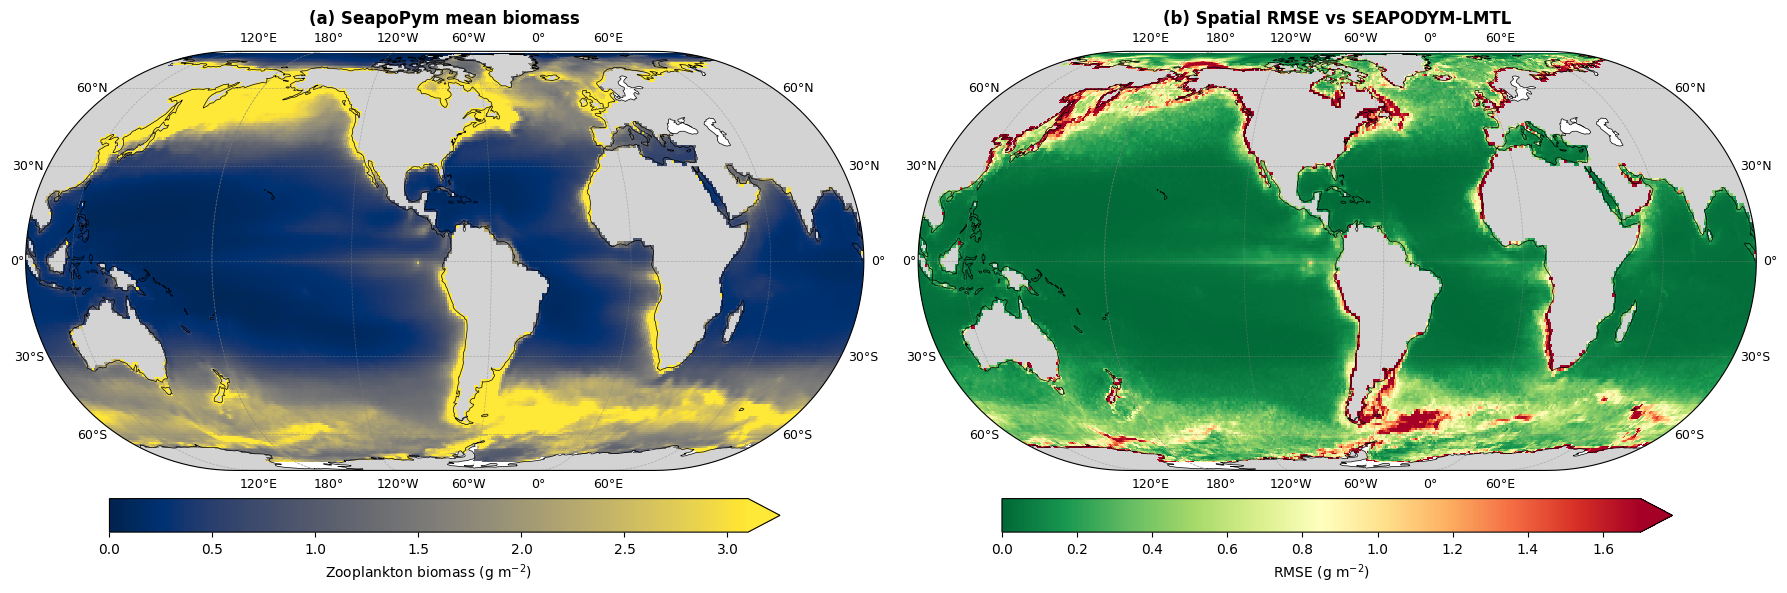

In [4]:
fig, axes = plt.subplots(
    1, 2, figsize=(18, 6),
    subplot_kw={"projection": ccrs.EckertIV(central_longitude=-80)},
)

PANELS = [
    {"data": pred_mean,    "cmap": "cividis",  "vmin": 0, "vmax": 3.1, "label": r"Zooplankton biomass (g m$^{-2}$)", "title": "(a) SeapoPym mean biomass"},
    {"data": spatial_rmse, "cmap": "RdYlGn_r", "vmin": 0, "vmax": 1.7, "label": r"RMSE (g m$^{-2}$)",                "title": "(b) Spatial RMSE vs SEAPODYM-LMTL"},
]
for ax, panel in zip(axes, PANELS):
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black", zorder=2)
    m = panel["data"].plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap=panel["cmap"], vmin=panel["vmin"], vmax=panel["vmax"],
        add_colorbar=False, zorder=1, extend="max",
    )
    ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--",
        x_inline=False, y_inline=False,
        xlabel_style={"size": 9}, ylabel_style={"size": 9},
    )
    cbar = plt.colorbar(m, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8, extend="max")
    cbar.set_label(panel["label"], fontsize=10)
    ax.set_title(panel["title"], fontsize=12, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "Figure_4.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_4.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()